# **Deep Learning based Models for Bitcoin Price Prediction Using Historical Market Data**

Data Fetching using `yfinance` for real time data

## **Libraries**

In [ ]:
import os
import shutil
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf

warnings.filterwarnings('ignore')

## **Data Fetching**

**Bitcoin Prices for last 2 Year**

In [ ]:
ticker = "BTC-USD"

btc = yf.Ticker(ticker)

print("Fetching Daily prices from last 2 year\n")
btc_daily_data = btc.history(period='2y', interval='1d')

print("Daily Data (Last 2 Year)")
btc_daily_data.tail()

Fetching Daily prices from last 2 year

Daily Data (Last 2 Year)


,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2026-04-03 00:00:00+00:00,66889.015625,67296.234375,66281.539062,66931.101562,22815543346,0.0,0.0
2026-04-04 00:00:00+00:00,66938.648438,67515.015625,66769.640625,67290.515625,15878814963,0.0,0.0
2026-04-05 00:00:00+00:00,67291.195312,69087.656250,66610.632812,68981.898438,22972648674,0.0,0.0
2026-04-06 00:00:00+00:00,68982.914062,70305.421875,68347.078125,68859.828125,39542143229,0.0,0.0
2026-04-07 00:00:00+00:00,68860.460938,69193.554688,68162.187500,68368.242188,33226725376,0.0,0.0


In [ ]:
btc_daily_data.shape

(731, 7)

**Converting to csv**

In [ ]:
os.makedirs("bitcoin_price_data", exist_ok=True)
btc_daily_data.to_csv("bitcoin_price_data/btc_daily_2year.csv")

## **Preprocessing**

In [ ]:
btc_daily_data = pd.read_csv("bitcoin_price_data/btc_daily_2year.csv")
btc_daily_data.tail()

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits
726,2026-04-03 00:00:00+00:00,66889.015625,67296.234375,66281.539062,66931.101562,22815543346,0.0,0.0
727,2026-04-04 00:00:00+00:00,66938.648438,67515.015625,66769.640625,67290.515625,15878814963,0.0,0.0
728,2026-04-05 00:00:00+00:00,67291.195312,69087.656250,66610.632812,68981.898438,22972648674,0.0,0.0
729,2026-04-06 00:00:00+00:00,68982.914062,70305.421875,68347.078125,68859.828125,39542143229,0.0,0.0
730,2026-04-07 00:00:00+00:00,68860.460938,69193.554688,68162.187500,68368.242188,33226725376,0.0,0.0


**Daily Data Preprocessing**

In [ ]:
btc_daily_data.columns

Index(['Date', 'Open', 'High', 'Low', 'Close', 'Volume', 'Dividends',
       'Stock Splits'],
      dtype='object')

In [ ]:
btc_daily_data["Target"] = btc_daily_data["Close"].shift(-1)

In [ ]:
# Keeping only required data

btc_daily_data.drop(['Stock Splits', 'Dividends'], axis=1, inplace=True)
btc_daily_data.columns

Index(['Date', 'Open', 'High', 'Low', 'Close', 'Volume', 'Target'], dtype='object')

In [ ]:
# Date Processing

btc_daily_data['Date'] = pd.to_datetime(btc_daily_data['Date'], utc=True).dt.date
btc_daily_data.tail()

,Date,Open,High,Low,Close,Volume,Target
726,2026-04-03,66889.015625,67296.234375,66281.539062,66931.101562,22815543346,67290.515625
727,2026-04-04,66938.648438,67515.015625,66769.640625,67290.515625,15878814963,68981.898438
728,2026-04-05,67291.195312,69087.656250,66610.632812,68981.898438,22972648674,68859.828125
729,2026-04-06,68982.914062,70305.421875,68347.078125,68859.828125,39542143229,68368.242188
730,2026-04-07,68860.460938,69193.554688,68162.187500,68368.242188,33226725376,NaN


## **EDA**

#### **Daily Data**

**Line Plot**

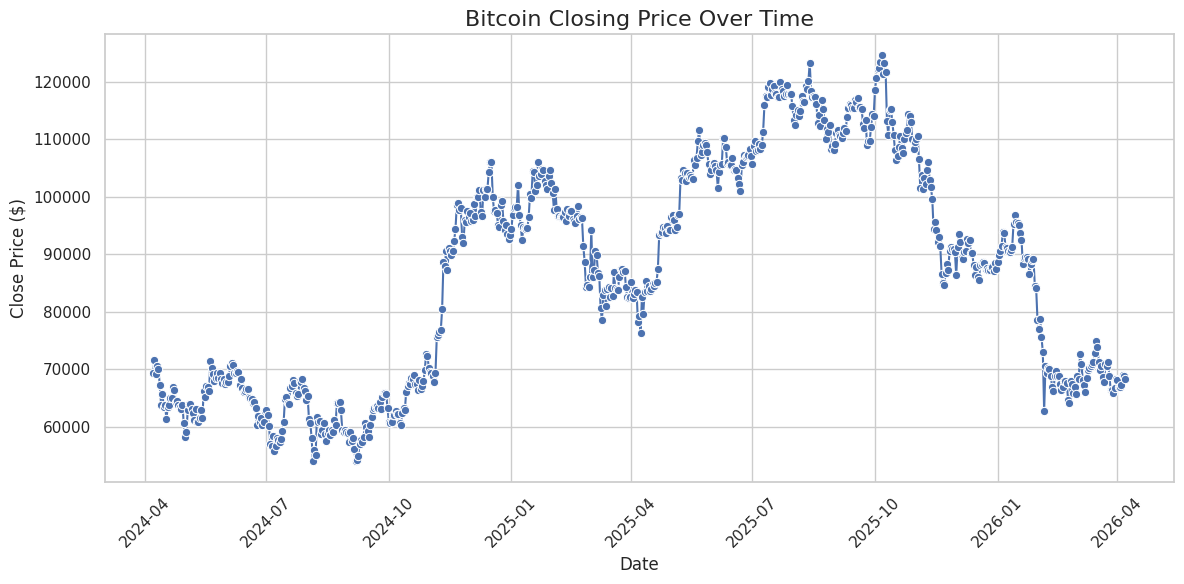

In [ ]:
btc_daily_data['Date'] = pd.to_datetime(btc_daily_data['Date'])

# 2. Set the visual style
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 6))

# 3. Create the line plot
line_plot = sns.lineplot(data=btc_daily_data, x='Date', y='Close', marker='o', color='b')

# 4. Customizing labels and title
plt.title('Bitcoin Closing Price Over Time', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Close Price ($)', fontsize=12)

# Rotate dates for better readability
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

**Candle Stick Chart**

In [ ]:
import plotly.graph_objects as go

# 2. Create the Candlestick figure
fig = go.Figure(data=[go.Candlestick(
    x=btc_daily_data['Date'],
    open=btc_daily_data['Open'],
    high=btc_daily_data['High'],
    low=btc_daily_data['Low'],
    close=btc_daily_data['Close'],
    increasing_line_color='green',
    decreasing_line_color='red'
)])

# 3. Customize layout
fig.update_layout(
    title='Bitcoin Candlestick Chart',
    yaxis_title='Price (USD)',
    xaxis_title='Date',
    xaxis_rangeslider_visible=True,
    template='plotly_white'
)

# 4. Show the plot
fig.show()

**Correlation Heatmap**

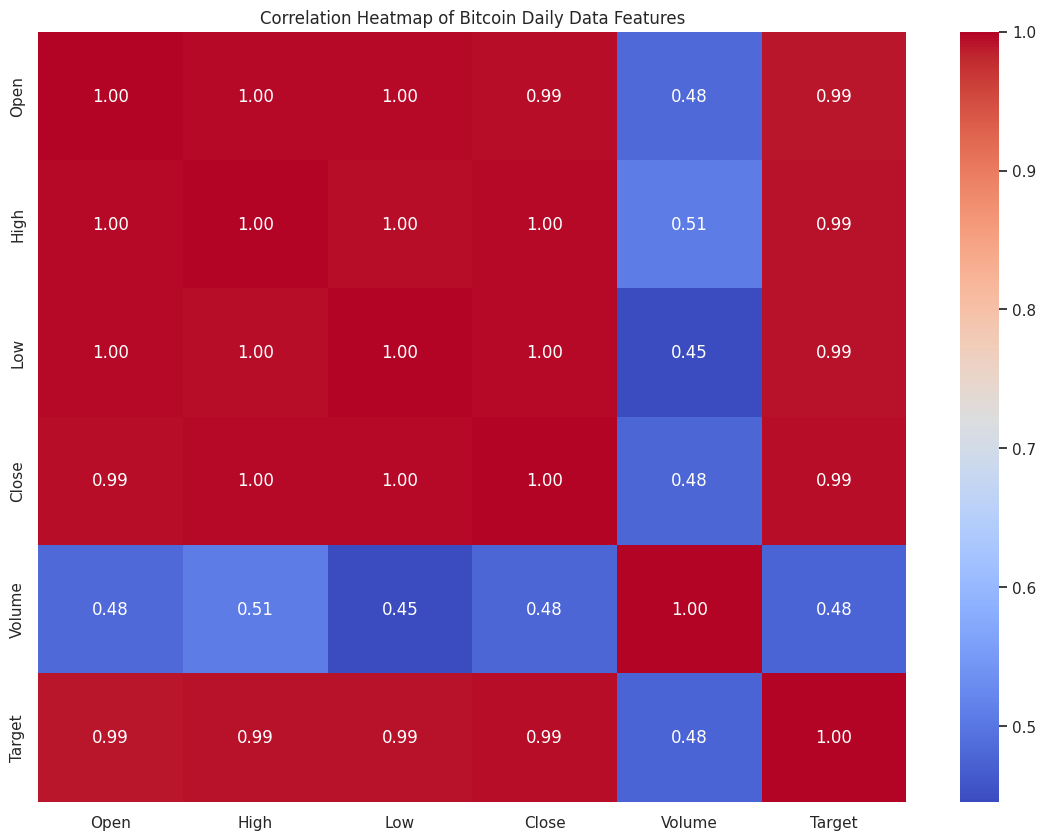

In [ ]:
plt.figure(figsize=(14, 10))
sns.heatmap(btc_daily_data.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of Bitcoin Daily Data Features')
plt.show()

**Distribution of Close Prices**

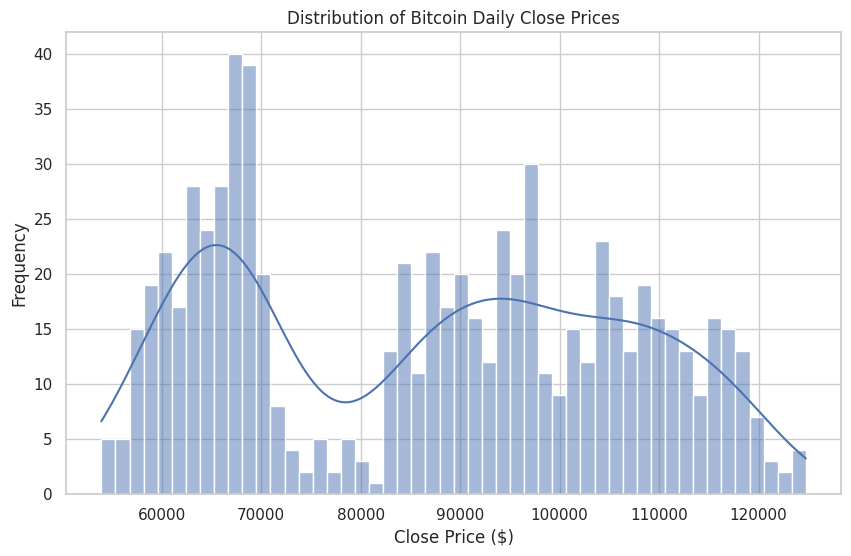

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(btc_daily_data['Close'], kde=True, bins=50)
plt.title('Distribution of Bitcoin Daily Close Prices')
plt.xlabel('Close Price ($)')
plt.ylabel('Frequency')
plt.show()

**Box Plot of Volume**

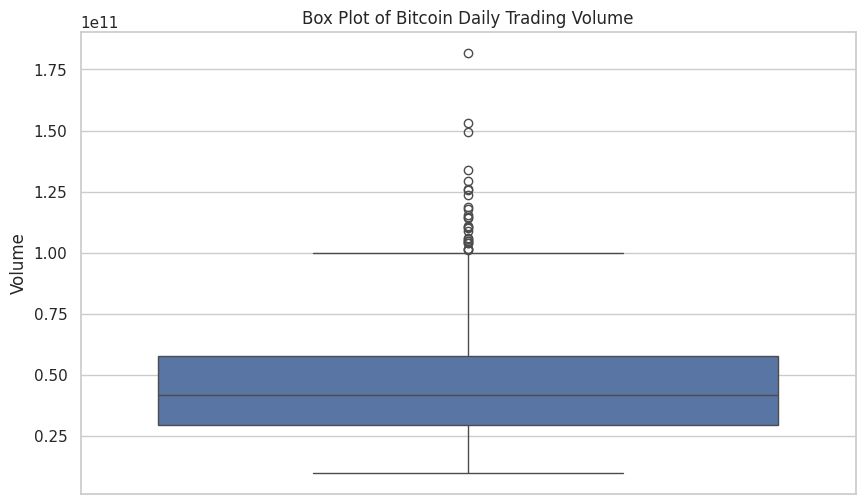

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(y=btc_daily_data['Volume'])
plt.title('Box Plot of Bitcoin Daily Trading Volume')
plt.ylabel('Volume')
plt.show()

In [ ]:
btc_daily_data.describe()

,Date,Open,High,Low,Close,Volume,Target
count,731,731.000000,731.000000,731.000000,731.000000,7.310000e+02,730.000000
mean,2025-04-07 00:00:00,86622.707159,88090.144414,85045.773299,86622.134645,4.637841e+10,86645.777906
min,2024-04-07 00:00:00,53949.085938,54838.144531,49121.238281,53948.753906,9.858199e+09,53948.753906
25%,2024-10-06 12:00:00,67390.742188,68457.246094,66259.578125,67383.843750,2.943033e+10,67375.847656
50%,2025-04-07 00:00:00,88344.703125,90267.460938,86717.914062,88344.000000,4.171957e+10,88387.066406
75%,2025-10-06 12:00:00,103722.496094,105397.570312,101491.984375,103723.925781,5.781190e+10,103734.283203
max,2026-04-07 00:00:00,124752.140625,126198.070312,123196.046875,124752.531250,1.817464e+11,124752.531250
std,NaN,19463.440399,19568.343357,19331.817939,19464.183651,2.392814e+10,19467.021948


## **Feature Engineering**

In [ ]:
# Price movement
btc_daily_data["Return"] = btc_daily_data["Close"].pct_change()

# Daily range (volatility proxy)
btc_daily_data["Range"] = btc_daily_data["High"] - btc_daily_data["Low"]

# Rolling averages
btc_daily_data["7_day_MA"] = btc_daily_data["Close"].rolling(7).mean()
btc_daily_data["14_day_MA"] = btc_daily_data["Close"].rolling(14).mean()
btc_daily_data["30_day_MA"] = btc_daily_data["Close"].rolling(30).mean()

# Rolling standard deviation (volatility)
btc_daily_data["7_day_Volatility"] = btc_daily_data["Close"].rolling(7).std()
btc_daily_data["30_day_Volatility"] = btc_daily_data["Close"].rolling(30).std()

# Momentum
btc_daily_data["7_day_Momentum"] = btc_daily_data["Close"] - btc_daily_data["Close"].shift(7)

# Lag features
btc_daily_data["Lag_1"] = btc_daily_data["Close"].shift(1)
btc_daily_data["Lag_2"] = btc_daily_data["Close"].shift(2)
btc_daily_data["Lag_3"] = btc_daily_data["Close"].shift(3)
btc_daily_data["Lag_7"] = btc_daily_data["Close"].shift(7)

**Rolling Mean**

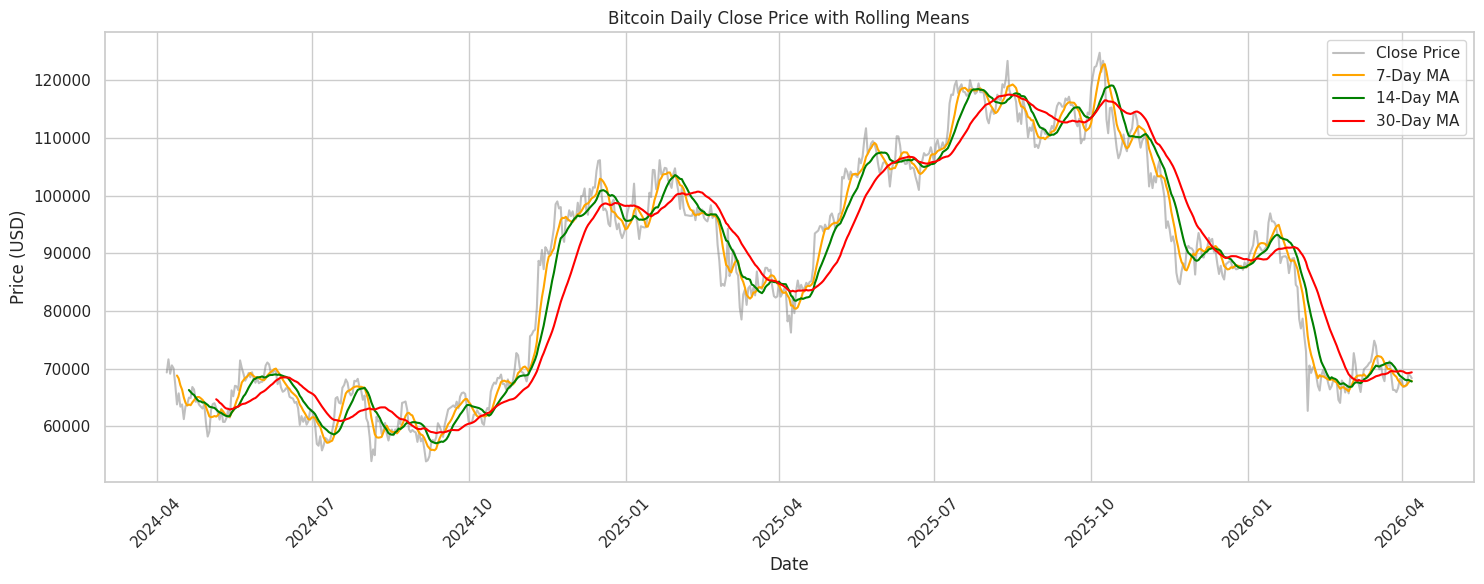

In [ ]:
# Plot Rolling Means
plt.figure(figsize=(15, 6))
plt.plot(btc_daily_data['Date'], btc_daily_data['Close'], label='Close Price', color='gray', alpha=0.5)
plt.plot(btc_daily_data['Date'], btc_daily_data['7_day_MA'], label='7-Day MA', color='orange')
plt.plot(btc_daily_data['Date'], btc_daily_data['14_day_MA'], label='14-Day MA', color='green')
plt.plot(btc_daily_data['Date'], btc_daily_data['30_day_MA'], label='30-Day MA', color='red')
plt.title('Bitcoin Daily Close Price with Rolling Means')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Rolling Volatility**

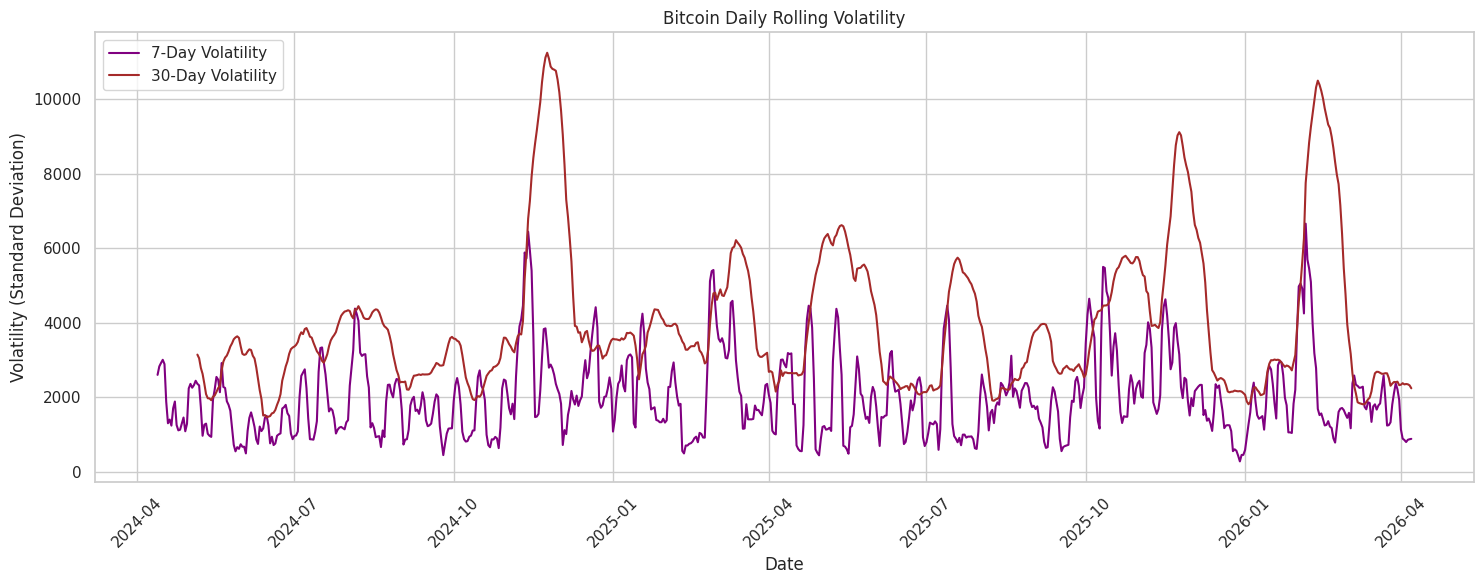

In [ ]:
plt.figure(figsize=(15, 6))
plt.plot(btc_daily_data['Date'], btc_daily_data['7_day_Volatility'], label='7-Day Volatility', color='purple')
plt.plot(btc_daily_data['Date'], btc_daily_data['30_day_Volatility'], label='30-Day Volatility', color='brown')
plt.title('Bitcoin Daily Rolling Volatility')
plt.xlabel('Date')
plt.ylabel('Volatility (Standard Deviation)')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [ ]:
btc_daily_data.tail()

,Date,Open,High,Low,Close,Volume,Target,Return,Range,7_day_MA,14_day_MA,30_day_MA,7_day_Volatility,30_day_Volatility,7_day_Momentum,Lag_1,Lag_2,Lag_3,Lag_7
726,2026-04-03,66889.015625,67296.234375,66281.539062,66931.101562,22815543346,67290.515625,0.000636,1014.695312,67013.943080,68109.066964,69340.396615,851.503708,2344.877611,592.726562,66888.570312,68078.554688,68233.312500,66338.375000
727,2026-04-04,66938.648438,67515.015625,66769.640625,67290.515625,15878814963,68981.898438,0.005370,745.375000,67152.631696,68007.566406,69222.042969,796.892096,2356.097578,970.820312,66931.101562,66888.570312,68078.554688,66319.695312
728,2026-04-05,67291.195312,69087.656250,66610.632812,68981.898438,22972648674,68859.828125,0.025136,2477.023438,67585.056920,68088.758371,69250.223177,857.611903,2347.706902,3026.976562,67290.515625,66931.101562,66888.570312,65954.921875
729,2026-04-06,68982.914062,70305.421875,68347.078125,68859.828125,39542143229,68368.242188,-0.001770,1958.343750,67894.825893,67941.970424,69303.130990,872.524236,2319.315567,2168.382812,68981.898438,67290.515625,66931.101562,66691.445312
730,2026-04-07,68860.460938,69193.554688,68162.187500,68368.242188,33226725376,NaN,-0.007139,1031.367188,67914.101562,67788.426339,69383.079687,882.679651,2240.447608,134.929688,68859.828125,68981.898438,67290.515625,68233.312500


In [ ]:
btc_daily_data.columns

Index(['Date', 'Open', 'High', 'Low', 'Close', 'Volume', 'Target', 'Return',
       'Range', '7_day_MA', '14_day_MA', '30_day_MA', '7_day_Volatility',
       '30_day_Volatility', '7_day_Momentum', 'Lag_1', 'Lag_2', 'Lag_3',
       'Lag_7'],
      dtype='object')

## **Model Building**

#### **Imports**

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

In [ ]:
data = btc_daily_data.dropna().copy()

In [ ]:
features = [
    'Open', 'High', 'Low', 'Close', 'Volume', 'Return', 'Range',
    '7_day_MA', '14_day_MA', '30_day_MA', '7_day_Volatility',
    '30_day_Volatility', '7_day_Momentum', 'Lag_1', 'Lag_2', 'Lag_3', 'Lag_7'
]
target = 'Target'

X = data[features].values
y = data[target].values.reshape(-1, 1) # Reshape for scaler

In [ ]:
# Scale the data
scaler_X = MinMaxScaler(feature_range=(0, 1))
X_scaled = scaler_X.fit_transform(X)

scaler_y = MinMaxScaler(feature_range=(0, 1))
y_scaled = scaler_y.fit_transform(y)

In [ ]:
# Create sequences for RNN
def create_sequences(X, y, time_steps):
    Xs, ys = [], []
    for i in range(len(X) - time_steps):
        Xs.append(X[i:(i + time_steps)])
        ys.append(y[i + time_steps])
    return np.array(Xs), np.array(ys)

In [ ]:

time_steps = 30 # Use 30 days history to predict the next day
X_seq, y_seq = create_sequences(X_scaled, y_scaled, time_steps)

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X_seq, y_seq, test_size=0.2, random_state=42, shuffle=False
)

print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (536, 30, 17)
y_train shape: (536, 1)
X_test shape: (135, 30, 17)
y_test shape: (135, 1)


#### **LSTM Model**

In [ ]:
lstm_model = Sequential([
    LSTM(units=50, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])),
    Dropout(0.2),
    LSTM(units=50, return_sequences=False),
    Dropout(0.2),
    Dense(units=1) # Output layer for single price prediction
])

In [ ]:
lstm_model.compile(optimizer='adam', loss='mean_squared_error')
lstm_model.summary()

Model: "sequential_18"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_14 (LSTM)                  │ (None, 30, 50)         │        13,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_36 (Dropout)            │ (None, 30, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_15 (LSTM)                  │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_37 (Dropout)            │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33,851 (132.23 KB)

 Trainable params: 33,851 (132.23 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
lstm_history = lstm_model.fit(
    X_train, y_train,
    epochs=50, # You can adjust the number of epochs
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

Epoch 1/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 5s 61ms/step - loss: 0.1731 - val_loss: 0.0168
Epoch 2/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - loss: 0.0235 - val_loss: 0.0139
Epoch 3/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - loss: 0.0125 - val_loss: 0.0126
Epoch 4/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - loss: 0.0095 - val_loss: 0.0137
Epoch 5/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - loss: 0.0094 - val_loss: 0.0116
Epoch 6/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 57ms/step - loss: 0.0088 - val_loss: 0.0110
Epoch 7/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step - loss: 0.0085 - val_loss: 0.0124
Epoch 8/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 57ms/step - loss: 0.0083 - val_loss: 0.0129
Epoch 9/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step - loss: 0.0078 - val_loss: 0.0101
Epoch 10/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - loss: 0.0073 - val_loss: 0.0104
Epoch 11/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - loss: 0.0078 - val_loss: 0.0105
Epoch 12/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - loss: 0.0

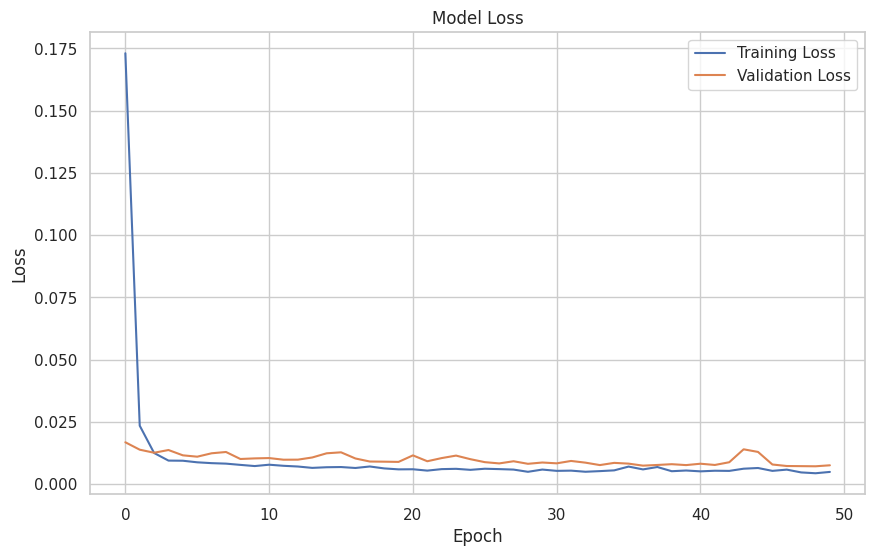

In [ ]:
# Plot training history
plt.figure(figsize=(10, 6))
plt.plot(lstm_history.history['loss'], label='Training Loss')
plt.plot(lstm_history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [ ]:
from sklearn.metrics import r2_score, mean_absolute_percentage_error

y_pred_scaled = lstm_model.predict(X_test)

# Inverse transform the predictions and actual values
y_pred = scaler_y.inverse_transform(y_pred_scaled)
y_true = scaler_y.inverse_transform(y_test)

# Calculate evaluation metrics
lstm_rmse = np.sqrt(mean_squared_error(y_true, y_pred))
lstm_mae = mean_absolute_error(y_true, y_pred)
lstm_r2 = r2_score(y_true, y_pred)
lstm_mape = mean_absolute_percentage_error(y_true, y_pred)

print(f"\nRoot Mean Squared Error (RMSE): {lstm_rmse:.2f}")
print(f"Mean Absolute Error (MAE): {lstm_mae:.2f}")
print(f"R-squared (R2): {lstm_r2:.2f}")
print(f"Mean Absolute Percentage Error (MAPE): {lstm_mape:.2%}")

5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 87ms/step

Root Mean Squared Error (RMSE): 3990.81
Mean Absolute Error (MAE): 2988.32
R-squared (R2): 0.86
Mean Absolute Percentage Error (MAPE): 3.93%


In [ ]:
# Store metrics in a DataFrame
metrics_df = pd.DataFrame({
    'Metric': ['RMSE', 'MAE', 'R2', 'MAPE'],
    'Value': [lstm_rmse, lstm_mae, lstm_r2, lstm_mape]
})

print("\nEvaluation Metrics:")
metrics_df


Evaluation Metrics:


,Metric,Value
0,RMSE,3990.808610
1,MAE,2988.316869
2,R2,0.862125
3,MAPE,0.039266


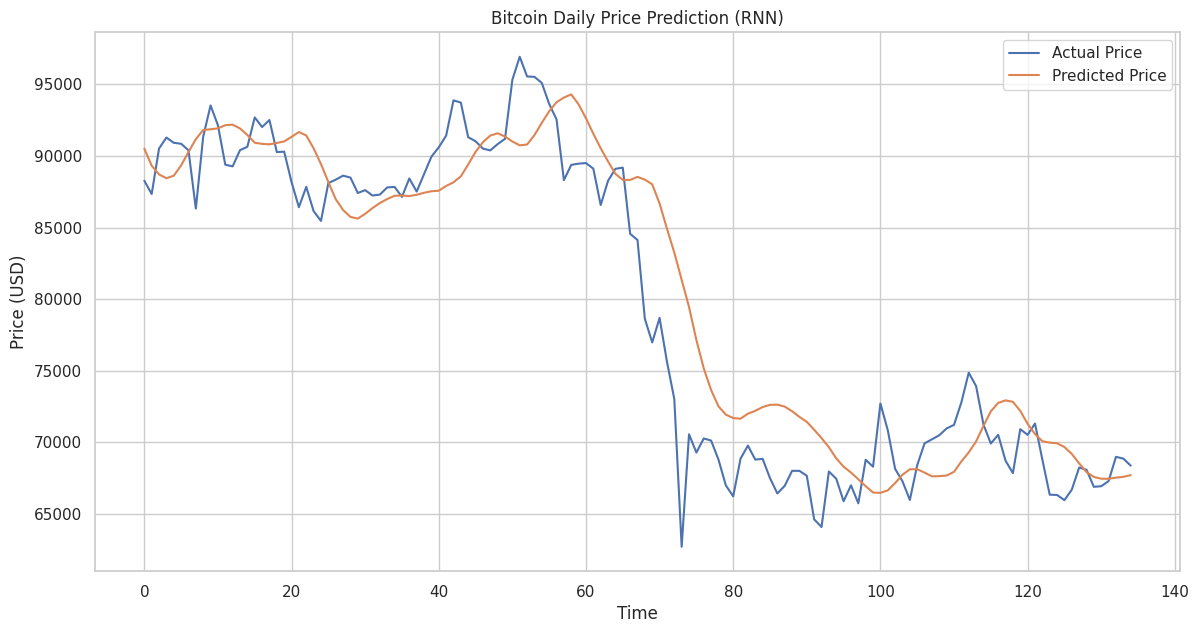

In [ ]:
plt.figure(figsize=(14, 7))
plt.plot(y_true, label='Actual Price')
plt.plot(y_pred, label='Predicted Price')
plt.title('Bitcoin Daily Price Prediction (RNN)')
plt.xlabel('Time')
plt.ylabel('Price (USD)')
plt.legend()
plt.show()

#### **RNN Model**

In [ ]:
from tensorflow.keras.layers import SimpleRNN

# Build the RNN model
rnn_model = Sequential([
    SimpleRNN(units=60, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])),
    Dropout(0.2),
    SimpleRNN(units=60, return_sequences=False),
    Dropout(0.2),
    Dense(units=1)
])

In [ ]:
rnn_model.compile(optimizer='adam', loss='mean_squared_error')
rnn_model.summary()

Model: "sequential_19"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_12 (SimpleRNN)       │ (None, 30, 60)         │         4,680 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_38 (Dropout)            │ (None, 30, 60)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_13 (SimpleRNN)       │ (None, 60)             │         7,260 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_39 (Dropout)            │ (None, 60)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 1)              │            61 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,001 (46.88 KB)

 Trainable params: 12,001 (46.88 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history_rnn = rnn_model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

Epoch 1/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 4s 49ms/step - loss: 0.7954 - val_loss: 0.0831
Epoch 2/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.2924 - val_loss: 0.0468
Epoch 3/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.2241 - val_loss: 0.0168
Epoch 4/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.1861 - val_loss: 0.0112
Epoch 5/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.1748 - val_loss: 0.0221
Epoch 6/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.1441 - val_loss: 0.0160
Epoch 7/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.1163 - val_loss: 0.0559
Epoch 8/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.1249 - val_loss: 0.0153
Epoch 9/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.1139 - val_loss: 0.0349
Epoch 10/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.1005 - val_loss: 0.0254
Epoch 11/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0879 - val_loss: 0.0142
Epoch 12/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0

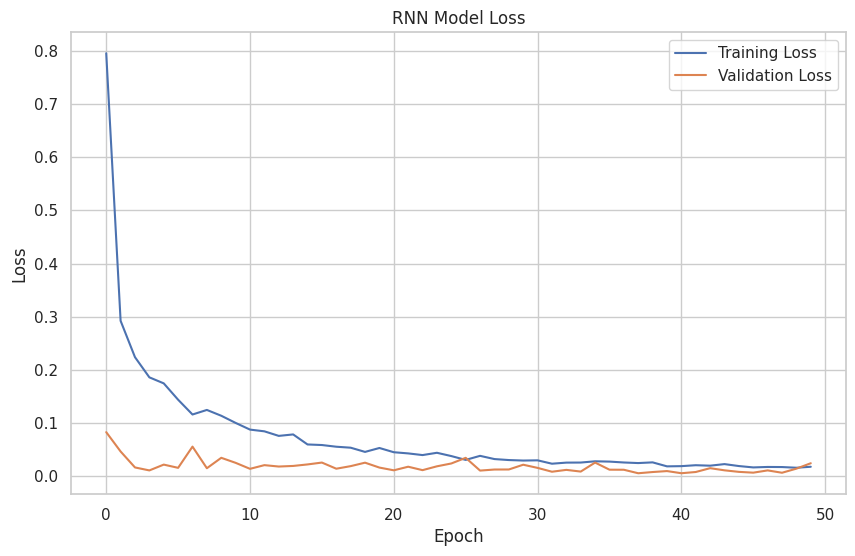

In [ ]:
# Plot training history
plt.figure(figsize=(10, 6))
plt.plot(history_rnn.history['loss'], label='Training Loss')
plt.plot(history_rnn.history['val_loss'], label='Validation Loss')
plt.title('RNN Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [ ]:
y_pred_scaled_rnn = rnn_model.predict(X_test)
y_pred_rnn = scaler_y.inverse_transform(y_pred_scaled_rnn)
y_true_rnn = scaler_y.inverse_transform(y_test)

rmse_rnn = np.sqrt(mean_squared_error(y_true_rnn, y_pred_rnn))
mae_rnn = mean_absolute_error(y_true_rnn, y_pred_rnn)
r2_rnn = r2_score(y_true_rnn, y_pred_rnn)
mape_rnn = mean_absolute_percentage_error(y_true_rnn, y_pred_rnn)

print(f"\nRNN Model Evaluation:")
print(f"Root Mean Squared Error (RMSE): {rmse_rnn:.2f}")
print(f"Mean Absolute Error (MAE): {mae_rnn:.2f}")
print(f"R-squared (R2): {r2_rnn:.2f}")
print(f"Mean Absolute Percentage Error (MAPE): {mape_rnn:.2%}")

5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 71ms/step

RNN Model Evaluation:
Root Mean Squared Error (RMSE): 6769.36
Mean Absolute Error (MAE): 5834.86
R-squared (R2): 0.60
Mean Absolute Percentage Error (MAPE): 7.41%


In [ ]:
metrics_df_rnn = pd.DataFrame({
    'Metric': ['RMSE', 'MAE', 'R2', 'MAPE'],
    'Value': [rmse_rnn, mae_rnn, r2_rnn, mape_rnn]
})

print("\nEvaluation Metrics for RNN Model:")
metrics_df_rnn


Evaluation Metrics for RNN Model:


,Metric,Value
0,RMSE,6769.355393
1,MAE,5834.861198
2,R2,0.603304
3,MAPE,0.074071


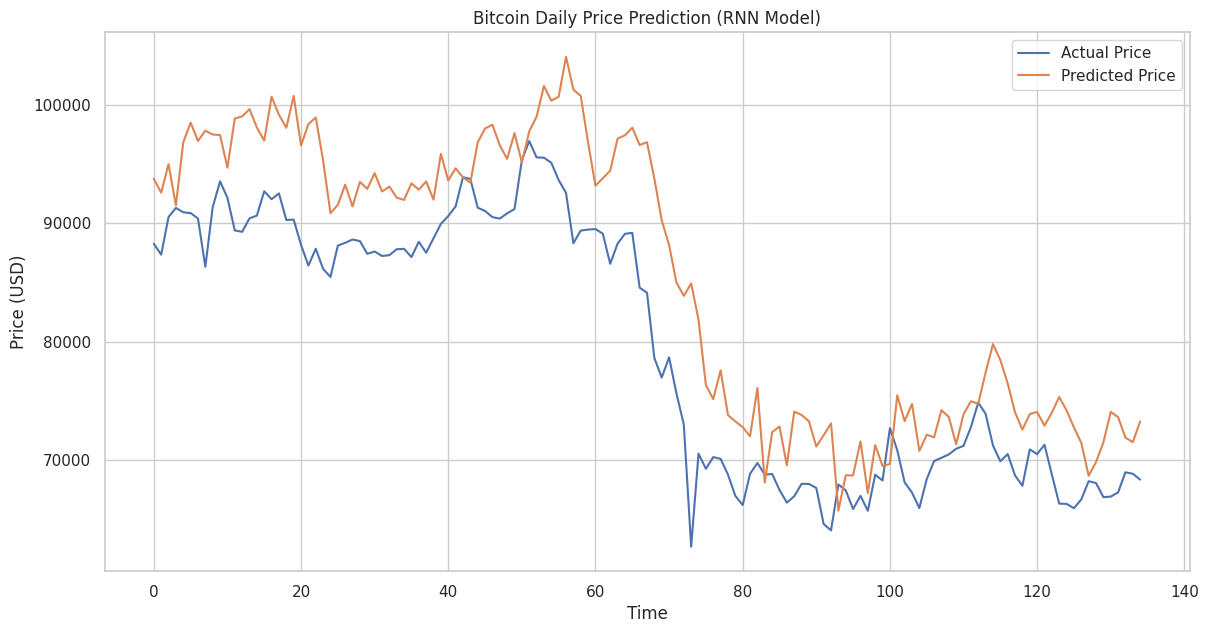

In [ ]:
plt.figure(figsize=(14, 7))
plt.plot(y_true_rnn, label='Actual Price')
plt.plot(y_pred_rnn, label='Predicted Price')
plt.title('Bitcoin Daily Price Prediction (RNN Model)')
plt.xlabel('Time')
plt.ylabel('Price (USD)')
plt.legend()
plt.show()

#### **GRU Model**


In [ ]:
from tensorflow.keras.layers import GRU

# Build the GRU model
gru_model = Sequential([
    GRU(units=50, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])),
    Dropout(0.2),
    GRU(units=50, return_sequences=False),
    Dropout(0.2),
    Dense(units=1)
])

In [ ]:
gru_model.compile(optimizer='adam', loss='mean_squared_error')
gru_model.summary()

Model: "sequential_20"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru_10 (GRU)                    │ (None, 30, 50)         │        10,350 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_40 (Dropout)            │ (None, 30, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_11 (GRU)                    │ (None, 50)             │        15,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_41 (Dropout)            │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,701 (100.39 KB)

 Trainable params: 25,701 (100.39 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history_gru = gru_model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

Epoch 1/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 5s 75ms/step - loss: 0.1634 - val_loss: 0.0183
Epoch 2/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - loss: 0.0297 - val_loss: 0.0224
Epoch 3/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 56ms/step - loss: 0.0174 - val_loss: 0.0117
Epoch 4/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 70ms/step - loss: 0.0138 - val_loss: 0.0102
Epoch 5/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 73ms/step - loss: 0.0144 - val_loss: 0.0096
Epoch 6/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step - loss: 0.0145 - val_loss: 0.0144
Epoch 7/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - loss: 0.0113 - val_loss: 0.0101
Epoch 8/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - loss: 0.0102 - val_loss: 0.0167
Epoch 9/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - loss: 0.0102 - val_loss: 0.0132
Epoch 10/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - loss: 0.0095 - val_loss: 0.0084
Epoch 11/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - loss: 0.0092 - val_loss: 0.0096
Epoch 12/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - loss: 0.0

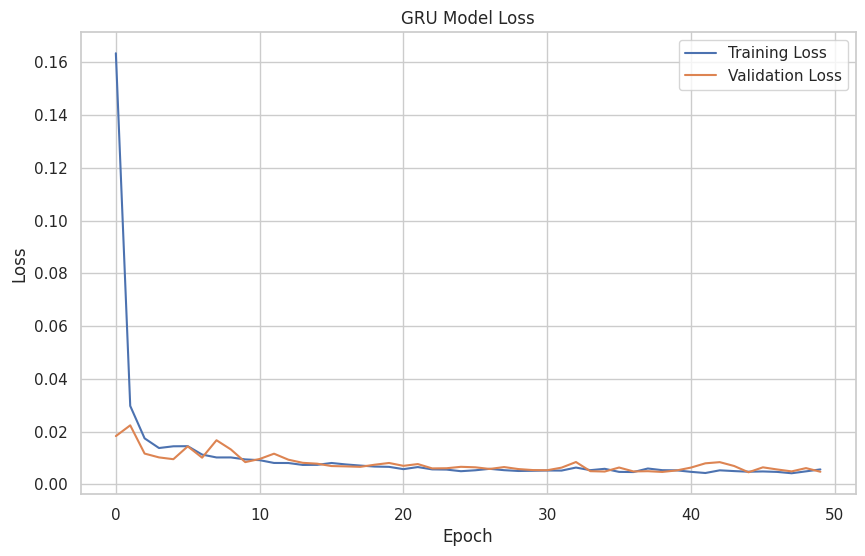

In [ ]:
# Plot training history
plt.figure(figsize=(10, 6))
plt.plot(history_gru.history['loss'], label='Training Loss')
plt.plot(history_gru.history['val_loss'], label='Validation Loss')
plt.title('GRU Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [ ]:
y_pred_scaled_gru = gru_model.predict(X_test)
y_pred_gru = scaler_y.inverse_transform(y_pred_scaled_gru)
y_true_gru = scaler_y.inverse_transform(y_test)

rmse_gru = np.sqrt(mean_squared_error(y_true_gru, y_pred_gru))
mae_gru = mean_absolute_error(y_true_gru, y_pred_gru)
r2_gru = r2_score(y_true_gru, y_pred_gru)
mape_gru = mean_absolute_percentage_error(y_true_gru, y_pred_gru)

print(f"\nGRU Model Evaluation:")
print(f"Root Mean Squared Error (RMSE): {rmse_gru:.2f}")
print(f"Mean Absolute Error (MAE): {mae_gru:.2f}")
print(f"R-squared (R2): {r2_gru:.2f}")
print(f"Mean Absolute Percentage Error (MAPE): {mape_gru:.2%}")

5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 101ms/step

GRU Model Evaluation:
Root Mean Squared Error (RMSE): 3365.25
Mean Absolute Error (MAE): 2618.99
R-squared (R2): 0.90
Mean Absolute Percentage Error (MAPE): 3.42%


In [ ]:
metrics_df_gru = pd.DataFrame({
    'Metric': ['RMSE', 'MAE', 'R2', 'MAPE'],
    'Value': [rmse_gru, mae_gru, r2_gru, mape_gru]
})

print("\nEvaluation Metrics for GRU Model:")
metrics_df_gru


Evaluation Metrics for GRU Model:


,Metric,Value
0,RMSE,3365.247106
1,MAE,2618.986024
2,R2,0.901961
3,MAPE,0.034228


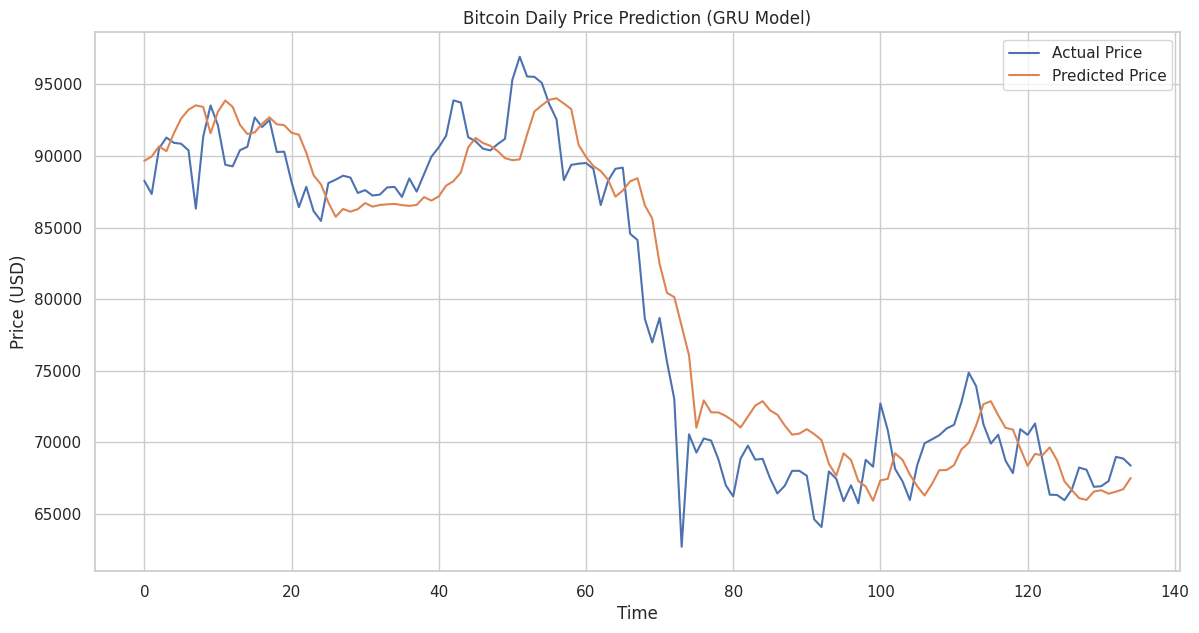

In [ ]:
plt.figure(figsize=(14, 7))
plt.plot(y_true_gru, label='Actual Price')
plt.plot(y_pred_gru, label='Predicted Price')
plt.title('Bitcoin Daily Price Prediction (GRU Model)')
plt.xlabel('Time')
plt.ylabel('Price (USD)')
plt.legend()
plt.show()

#### **Future Price Projections (3 Days)**


In [ ]:
def predict_future_days(model, initial_sequence, num_days, scaler_y):
    current_sequence = initial_sequence.copy()
    future_predictions_scaled = []

    for _ in range(num_days):
        # Predict the next day
        next_day_pred_scaled = model.predict(current_sequence.reshape(1, time_steps, -1))[0]
        future_predictions_scaled.append(next_day_pred_scaled)

        last_day_features = current_sequence[-1]
        predicted_day_features = np.copy(last_day_features)
        predicted_day_features[3] = next_day_pred_scaled[0]
        if 'Lag_1' in features:
            lag1_idx = features.index('Lag_1')
            predicted_day_features[lag1_idx] = current_sequence[-1, 3]
        if 'Lag_2' in features:
            lag2_idx = features.index('Lag_2')
            predicted_day_features[lag2_idx] = current_sequence[-2, 3]
        if 'Lag_3' in features:
            lag3_idx = features.index('Lag_3')
            predicted_day_features[lag3_idx] = current_sequence[-3, 3]
        if 'Lag_7' in features:
            lag7_idx = features.index('Lag_7')
            predicted_day_features[lag7_idx] = current_sequence[-7, 3]

        predicted_day_features[0] = next_day_pred_scaled[0]
        predicted_day_features[1] = next_day_pred_scaled[0] * 1.01
        predicted_day_features[2] = next_day_pred_scaled[0] * 0.99

        current_sequence = np.vstack((current_sequence[1:], predicted_day_features))

    future_predictions_scaled = np.array(future_predictions_scaled)
    return scaler_y.inverse_transform(future_predictions_scaled)

In [ ]:
last_sequence_X = X_scaled[-time_steps:]

future_predictions_lstm1 = predict_future_days(lstm_model, last_sequence_X, 3, scaler_y)
print(f"\nLSTM Model 1 - Projected prices for the next 3 days: {future_predictions_lstm1.flatten()}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step

LSTM Model 1 - Projected prices for the next 3 days: [68031.305 68303.    68532.73 ]


In [ ]:
future_predictions_rnn = predict_future_days(rnn_model, last_sequence_X, 3, scaler_y)
print(f"RNN Model - Projected prices for the next 3 days: {future_predictions_rnn.flatten()}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
RNN Model - Projected prices for the next 3 days: [70964.1   73678.29  76131.164]


In [ ]:
future_predictions_gru = predict_future_days(gru_model, last_sequence_X, 3, scaler_y)
print(f"GRU Model - Projected prices for the next 3 days: {future_predictions_gru.flatten()}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
GRU Model - Projected prices for the next 3 days: [67793.81 67740.37 67728.07]


In [ ]:
historical_close = scaler_y.inverse_transform(y_seq[-time_steps:]).flatten()
historical_dates = pd.to_datetime(data['Date'].iloc[-time_steps:]).tolist()

# Generate future dates
last_actual_date = historical_dates[-1]
future_dates = pd.date_range(start=last_actual_date + pd.Timedelta(days=1), periods=3).tolist()

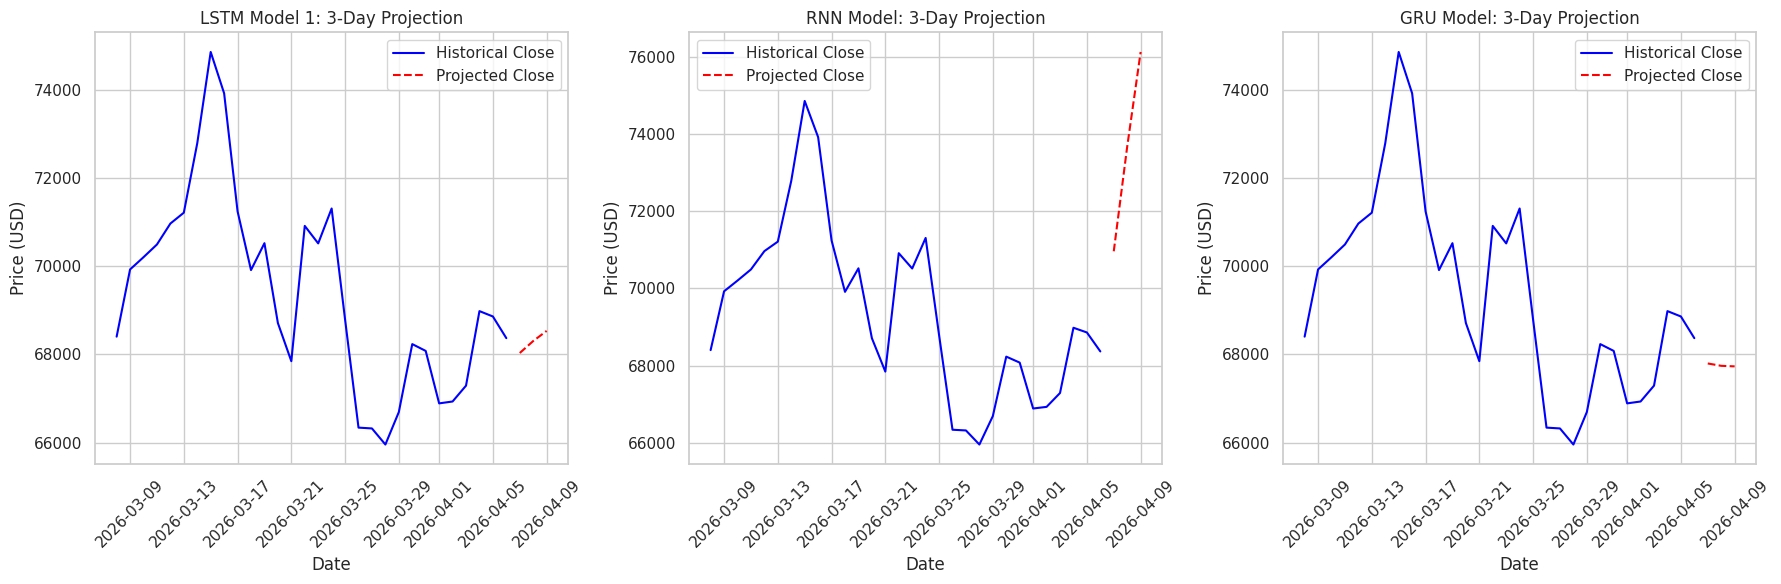

In [ ]:
plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
plt.plot(historical_dates, historical_close, label='Historical Close', color='blue')
plt.plot(future_dates, future_predictions_lstm1.flatten(), label='Projected Close', color='red', linestyle='--')
plt.title('LSTM Model 1: 3-Day Projection')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)

# Plot for RNN Model
plt.subplot(1, 3, 2)
plt.plot(historical_dates, historical_close, label='Historical Close', color='blue')
plt.plot(future_dates, future_predictions_rnn.flatten(), label='Projected Close', color='red', linestyle='--')
plt.title('RNN Model: 3-Day Projection')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)

# Plot for GRU Model
plt.subplot(1, 3, 3)
plt.plot(historical_dates, historical_close, label='Historical Close', color='blue')
plt.plot(future_dates, future_predictions_gru.flatten(), label='Projected Close', color='red', linestyle='--')
plt.title('GRU Model: 3-Day Projection')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
# Combine all metrics into a single DataFrame for comparison
all_metrics_df = pd.DataFrame({
    'Model': ['LSTM Model', 'RNN Model', 'GRU Model'],
    'RMSE': [lstm_rmse, rmse_rnn, rmse_gru],
    'MAE': [lstm_mae, mae_rnn, mae_gru],
    'R2': [lstm_r2, r2_rnn, r2_gru],
    'MAPE': [lstm_mape, mape_rnn, mape_gru]
})

print("\nCombined Evaluation Metrics:")
all_metrics_df


Combined Evaluation Metrics:


,Model,RMSE,MAE,R2,MAPE
0,LSTM Model,3990.808610,2988.316869,0.862125,0.039266
1,RNN Model,6769.355393,5834.861198,0.603304,0.074071
2,GRU Model,3365.247106,2618.986024,0.901961,0.034228


#### **Metric Comparison Plots**


In [ ]:
def plot_metric(metric):
    plt.figure(figsize=(14, 6))

    ax = sns.barplot(x='Model', y=metric, data=all_metrics_df, palette='viridis')

    if metric in ['RMSE', 'MAE', 'MAPE']:
        best_idx = all_metrics_df[metric].idxmin()
    else:
        best_idx = all_metrics_df[metric].idxmax()

    best_model = all_metrics_df.loc[best_idx, 'Model']

    for i, row in all_metrics_df.iterrows():
        bar = ax.patches[i]
        x = bar.get_x() + bar.get_width()/2
        y = bar.get_height()

        label = f'{row[metric]:.2%}' if metric == 'MAPE' else f'{row[metric]:.2f}'
        plt.text(x, y, label, ha='center', va='bottom')

        if row['Model'] == best_model:
            plt.text(x, y*1.05, '★', ha='center', color='red', fontsize=14)

    plt.title(metric)
    plt.show()

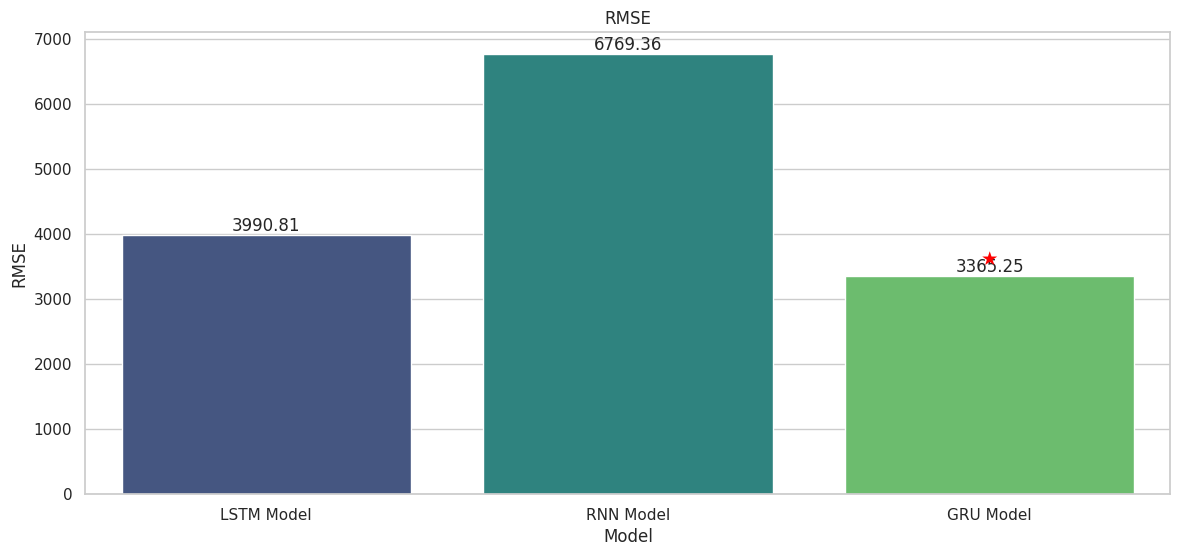

In [ ]:
plot_metric('RMSE')

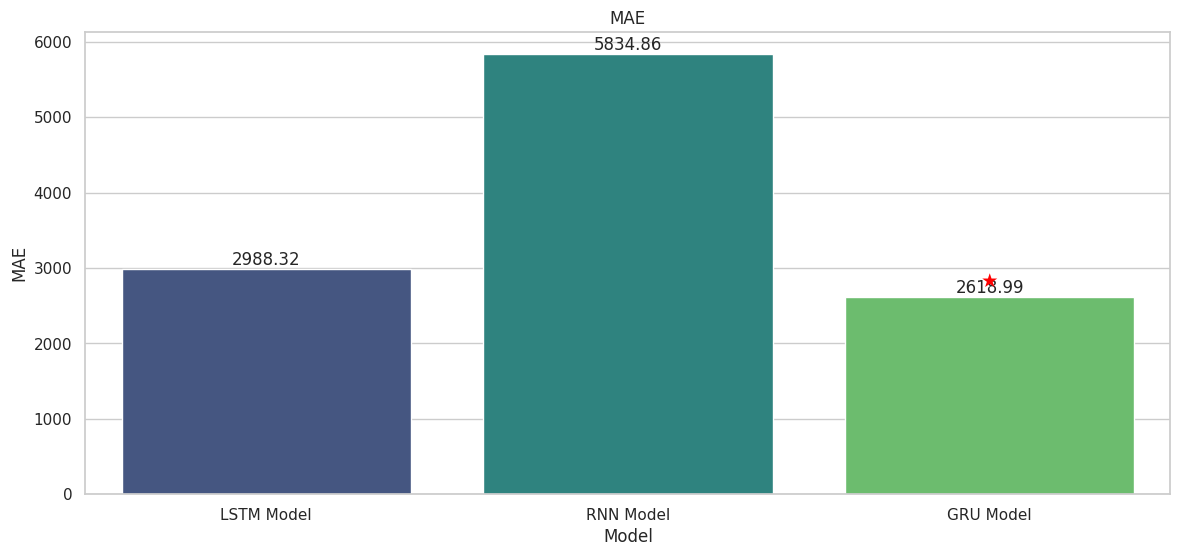

In [ ]:
plot_metric('MAE')

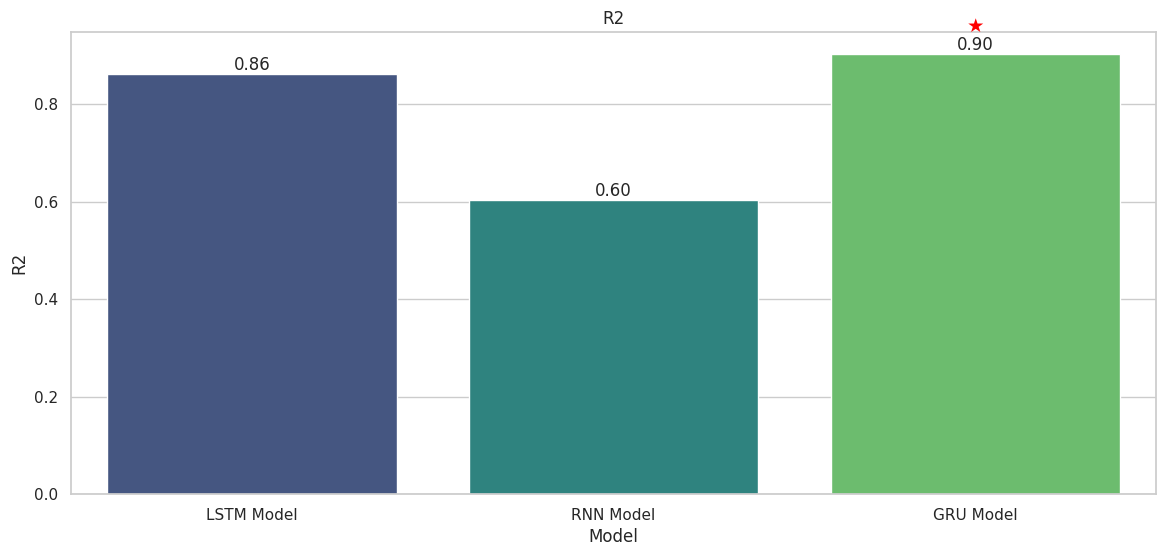

In [ ]:
plot_metric('R2')

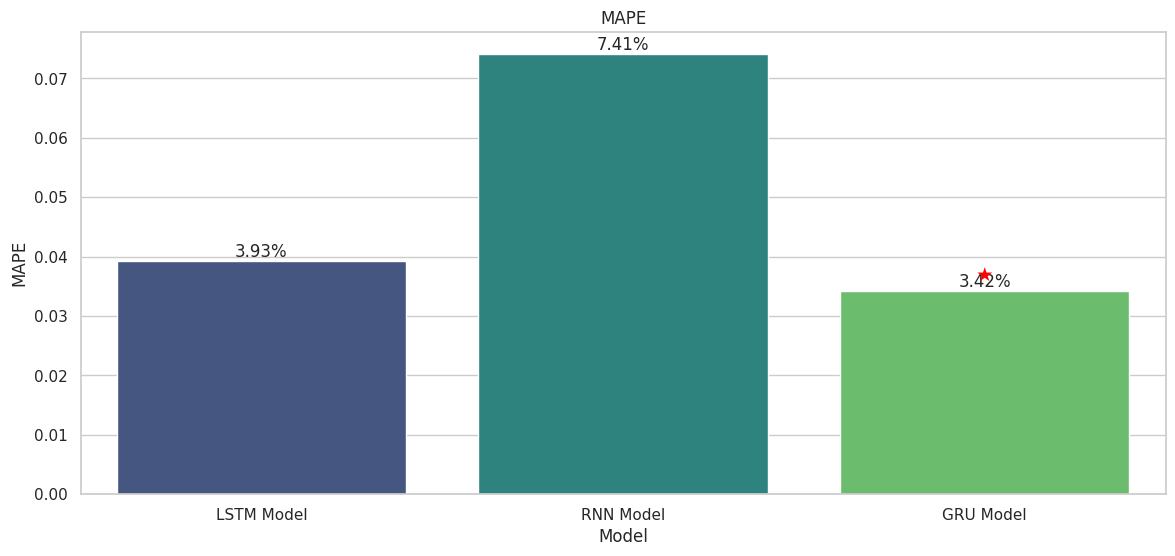

In [ ]:
plot_metric('MAPE')